# Linopy Fleet Replacement Model Demo


In [2]:
import linopy
import pandas as pd
import xarray as xr

m = linopy.Model()

In [3]:
horizon = 10
fleet_size = 5
max_age = 7

## Optimization variables


### Fleet variables


In [4]:
m.add_variables(
    coords={
        "time": range(horizon),
        "fleet_slot": range(fleet_size),
        "is_electric": [0, 1],
        "age": range(max_age),
    },
    binary=True,
    name="R",
)

Variable (time: 10, fleet_slot: 5, is_electric: 2, age: 7)
----------------------------------------------------------
[0, 0, 0, 0]: R[0, 0, 0, 0] ∈ {0, 1}
[0, 0, 0, 1]: R[0, 0, 0, 1] ∈ {0, 1}
[0, 0, 0, 2]: R[0, 0, 0, 2] ∈ {0, 1}
[0, 0, 0, 3]: R[0, 0, 0, 3] ∈ {0, 1}
[0, 0, 0, 4]: R[0, 0, 0, 4] ∈ {0, 1}
[0, 0, 0, 5]: R[0, 0, 0, 5] ∈ {0, 1}
[0, 0, 0, 6]: R[0, 0, 0, 6] ∈ {0, 1}
		...
[9, 4, 1, 0]: R[9, 4, 1, 0] ∈ {0, 1}
[9, 4, 1, 1]: R[9, 4, 1, 1] ∈ {0, 1}
[9, 4, 1, 2]: R[9, 4, 1, 2] ∈ {0, 1}
[9, 4, 1, 3]: R[9, 4, 1, 3] ∈ {0, 1}
[9, 4, 1, 4]: R[9, 4, 1, 4] ∈ {0, 1}
[9, 4, 1, 5]: R[9, 4, 1, 5] ∈ {0, 1}
[9, 4, 1, 6]: R[9, 4, 1, 6] ∈ {0, 1}

### Replacement decisions


In [5]:
decisions = ["KEEP", "REPLACE_DT", "REPLACE_BET"]

m.add_variables(
    coords={
        "time": range(horizon - 1),
        "fleet_slot": range(fleet_size),
        "is_electric": [0, 1],
        "age": range(max_age),
        "decision": decisions,
    },
    binary=True,
    name="x",
)

Variable (time: 9, fleet_slot: 5, is_electric: 2, age: 7, decision: 3)
----------------------------------------------------------------------
[0, 0, 0, 0, KEEP]: x[0, 0, 0, 0, KEEP] ∈ {0, 1}
[0, 0, 0, 0, REPLACE_DT]: x[0, 0, 0, 0, REPLACE_DT] ∈ {0, 1}
[0, 0, 0, 0, REPLACE_BET]: x[0, 0, 0, 0, REPLACE_BET] ∈ {0, 1}
[0, 0, 0, 1, KEEP]: x[0, 0, 0, 1, KEEP] ∈ {0, 1}
[0, 0, 0, 1, REPLACE_DT]: x[0, 0, 0, 1, REPLACE_DT] ∈ {0, 1}
[0, 0, 0, 1, REPLACE_BET]: x[0, 0, 0, 1, REPLACE_BET] ∈ {0, 1}
[0, 0, 0, 2, KEEP]: x[0, 0, 0, 2, KEEP] ∈ {0, 1}
		...
[8, 4, 1, 4, REPLACE_BET]: x[8, 4, 1, 4, REPLACE_BET] ∈ {0, 1}
[8, 4, 1, 5, KEEP]: x[8, 4, 1, 5, KEEP] ∈ {0, 1}
[8, 4, 1, 5, REPLACE_DT]: x[8, 4, 1, 5, REPLACE_DT] ∈ {0, 1}
[8, 4, 1, 5, REPLACE_BET]: x[8, 4, 1, 5, REPLACE_BET] ∈ {0, 1}
[8, 4, 1, 6, KEEP]: x[8, 4, 1, 6, KEEP] ∈ {0, 1}
[8, 4, 1, 6, REPLACE_DT]: x[8, 4, 1, 6, REPLACE_DT] ∈ {0, 1}
[8, 4, 1, 6, REPLACE_BET]: x[8, 4, 1, 6, REPLACE_BET] ∈ {0, 1}

## Constraints


### Initial fleet


In [6]:
R = m.variables["R"]

initial_fleet = [
    (0, 1),
    (0, 2),
    (0, 3),
    (1, 0),
    (1, 1),
]
# for slot in range(fleet_size):
slot = 0

for slot in range(fleet_size):
    is_electric, age = initial_fleet[slot]
    m.add_constraints(
        R.sel(time=0, fleet_slot=slot, is_electric=is_electric, age=age) == 1,
        name=f"initial_fleet_slot_{slot}",
    )

In [7]:
m.constraints["initial_fleet_slot_0"]

Constraint `initial_fleet_slot_0`
---------------------------------
+1 R[0, 0, 0, 1] = 1.0

### Feasability


In [8]:
# Each fleet slot must have exactly one vehicle at each time period
m.add_constraints(
    R.sum(dims=["is_electric", "age"]) == 1,
    name="single_vehicle_per_fleet_slot_and_time_period",
)

Constraint `single_vehicle_per_fleet_slot_and_time_period` [time: 10, fleet_slot: 5]:
-------------------------------------------------------------------------------------
[0, 0]: +1 R[0, 0, 0, 0] + 1 R[0, 0, 0, 1] + 1 R[0, 0, 0, 2] ... +1 R[0, 0, 1, 4] + 1 R[0, 0, 1, 5] + 1 R[0, 0, 1, 6] = 1.0
[0, 1]: +1 R[0, 1, 0, 0] + 1 R[0, 1, 0, 1] + 1 R[0, 1, 0, 2] ... +1 R[0, 1, 1, 4] + 1 R[0, 1, 1, 5] + 1 R[0, 1, 1, 6] = 1.0
[0, 2]: +1 R[0, 2, 0, 0] + 1 R[0, 2, 0, 1] + 1 R[0, 2, 0, 2] ... +1 R[0, 2, 1, 4] + 1 R[0, 2, 1, 5] + 1 R[0, 2, 1, 6] = 1.0
[0, 3]: +1 R[0, 3, 0, 0] + 1 R[0, 3, 0, 1] + 1 R[0, 3, 0, 2] ... +1 R[0, 3, 1, 4] + 1 R[0, 3, 1, 5] + 1 R[0, 3, 1, 6] = 1.0
[0, 4]: +1 R[0, 4, 0, 0] + 1 R[0, 4, 0, 1] + 1 R[0, 4, 0, 2] ... +1 R[0, 4, 1, 4] + 1 R[0, 4, 1, 5] + 1 R[0, 4, 1, 6] = 1.0
[1, 0]: +1 R[1, 0, 0, 0] + 1 R[1, 0, 0, 1] + 1 R[1, 0, 0, 2] ... +1 R[1, 0, 1, 4] + 1 R[1, 0, 1, 5] + 1 R[1, 0, 1, 6] = 1.0
[1, 1]: +1 R[1, 1, 0, 0] + 1 R[1, 1, 0, 1] + 1 R[1, 1, 0, 2] ... +1 R[1, 1, 1, 4] + 

In [9]:
x = m.variables["x"]

In [10]:
# Each fleet slot must have exactly one decision per vehicle per time period
m.add_constraints(
    x.sum(dims=["is_electric", "age", "decision"]) == 1,
    name="single_decision_per_fleet_slot_and_time_period",
)

Constraint `single_decision_per_fleet_slot_and_time_period` [time: 9, fleet_slot: 5]:
-------------------------------------------------------------------------------------
[0, 0]: +1 x[0, 0, 0, 0, KEEP] + 1 x[0, 0, 0, 0, REPLACE_DT] + 1 x[0, 0, 0, 0, REPLACE_BET] ... +1 x[0, 0, 1, 6, KEEP] + 1 x[0, 0, 1, 6, REPLACE_DT] + 1 x[0, 0, 1, 6, REPLACE_BET] = 1.0
[0, 1]: +1 x[0, 1, 0, 0, KEEP] + 1 x[0, 1, 0, 0, REPLACE_DT] + 1 x[0, 1, 0, 0, REPLACE_BET] ... +1 x[0, 1, 1, 6, KEEP] + 1 x[0, 1, 1, 6, REPLACE_DT] + 1 x[0, 1, 1, 6, REPLACE_BET] = 1.0
[0, 2]: +1 x[0, 2, 0, 0, KEEP] + 1 x[0, 2, 0, 0, REPLACE_DT] + 1 x[0, 2, 0, 0, REPLACE_BET] ... +1 x[0, 2, 1, 6, KEEP] + 1 x[0, 2, 1, 6, REPLACE_DT] + 1 x[0, 2, 1, 6, REPLACE_BET] = 1.0
[0, 3]: +1 x[0, 3, 0, 0, KEEP] + 1 x[0, 3, 0, 0, REPLACE_DT] + 1 x[0, 3, 0, 0, REPLACE_BET] ... +1 x[0, 3, 1, 6, KEEP] + 1 x[0, 3, 1, 6, REPLACE_DT] + 1 x[0, 3, 1, 6, REPLACE_BET] = 1.0
[0, 4]: +1 x[0, 4, 0, 0, KEEP] + 1 x[0, 4, 0, 0, REPLACE_DT] + 1 x[0, 4, 0, 0, REPLA

In [11]:
# No decision can be made for a vehicle that is not in the fleet slot
m.add_constraints(
    x <= R.isel(time=slice(0, horizon - 1)),
    name="no_decision_for_nonexistent_vehicle",
)

Constraint `no_decision_for_nonexistent_vehicle` [time: 9, fleet_slot: 5, is_electric: 2, age: 7, decision: 3]:
---------------------------------------------------------------------------------------------------------------
[0, 0, 0, 0, KEEP]: +1 x[0, 0, 0, 0, KEEP] - 1 R[0, 0, 0, 0]               ≤ -0.0
[0, 0, 0, 0, REPLACE_DT]: +1 x[0, 0, 0, 0, REPLACE_DT] - 1 R[0, 0, 0, 0]   ≤ -0.0
[0, 0, 0, 0, REPLACE_BET]: +1 x[0, 0, 0, 0, REPLACE_BET] - 1 R[0, 0, 0, 0] ≤ -0.0
[0, 0, 0, 1, KEEP]: +1 x[0, 0, 0, 1, KEEP] - 1 R[0, 0, 0, 1]               ≤ -0.0
[0, 0, 0, 1, REPLACE_DT]: +1 x[0, 0, 0, 1, REPLACE_DT] - 1 R[0, 0, 0, 1]   ≤ -0.0
[0, 0, 0, 1, REPLACE_BET]: +1 x[0, 0, 0, 1, REPLACE_BET] - 1 R[0, 0, 0, 1] ≤ -0.0
[0, 0, 0, 2, KEEP]: +1 x[0, 0, 0, 2, KEEP] - 1 R[0, 0, 0, 2]               ≤ -0.0
		...
[8, 4, 1, 4, REPLACE_BET]: +1 x[8, 4, 1, 4, REPLACE_BET] - 1 R[8, 4, 1, 4] ≤ -0.0
[8, 4, 1, 5, KEEP]: +1 x[8, 4, 1, 5, KEEP] - 1 R[8, 4, 1, 5]               ≤ -0.0
[8, 4, 1, 5, REPLACE_DT]: +1 x[8

### Replace at max age


In [12]:
m.add_constraints(
    x.sel(age=max_age - 1, decision="KEEP") == 0,
    name="replace_at_max_age",
)

Constraint `replace_at_max_age` [time: 9, fleet_slot: 5, is_electric: 2]:
-------------------------------------------------------------------------
[0, 0, 0]: +1 x[0, 0, 0, 6, KEEP] = -0.0
[0, 0, 1]: +1 x[0, 0, 1, 6, KEEP] = -0.0
[0, 1, 0]: +1 x[0, 1, 0, 6, KEEP] = -0.0
[0, 1, 1]: +1 x[0, 1, 1, 6, KEEP] = -0.0
[0, 2, 0]: +1 x[0, 2, 0, 6, KEEP] = -0.0
[0, 2, 1]: +1 x[0, 2, 1, 6, KEEP] = -0.0
[0, 3, 0]: +1 x[0, 3, 0, 6, KEEP] = -0.0
		...
[8, 1, 1]: +1 x[8, 1, 1, 6, KEEP] = -0.0
[8, 2, 0]: +1 x[8, 2, 0, 6, KEEP] = -0.0
[8, 2, 1]: +1 x[8, 2, 1, 6, KEEP] = -0.0
[8, 3, 0]: +1 x[8, 3, 0, 6, KEEP] = -0.0
[8, 3, 1]: +1 x[8, 3, 1, 6, KEEP] = -0.0
[8, 4, 0]: +1 x[8, 4, 0, 6, KEEP] = -0.0
[8, 4, 1]: +1 x[8, 4, 1, 6, KEEP] = -0.0

### Transition function


In [13]:
# Keep-transitions: If we keep a vehicle, it ages by 1 in the next period
m.add_constraints(
    R.isel(time=slice(1, None), age=slice(1, max_age)).assign_coords(
        time=range(horizon - 1),
        age=range(max_age - 1),
    )
    >= x.sel(decision="KEEP").isel(age=slice(0, max_age - 1)),
    name="keep_transitions",
)

Constraint `keep_transitions` [fleet_slot: 5, is_electric: 2, time: 9, age: 6]:
-------------------------------------------------------------------------------
[0, 0, 0, 0]: +1 R[1, 0, 0, 1] - 1 x[0, 0, 0, 0, KEEP] ≥ -0.0
[0, 0, 0, 1]: +1 R[1, 0, 0, 2] - 1 x[0, 0, 0, 1, KEEP] ≥ -0.0
[0, 0, 0, 2]: +1 R[1, 0, 0, 3] - 1 x[0, 0, 0, 2, KEEP] ≥ -0.0
[0, 0, 0, 3]: +1 R[1, 0, 0, 4] - 1 x[0, 0, 0, 3, KEEP] ≥ -0.0
[0, 0, 0, 4]: +1 R[1, 0, 0, 5] - 1 x[0, 0, 0, 4, KEEP] ≥ -0.0
[0, 0, 0, 5]: +1 R[1, 0, 0, 6] - 1 x[0, 0, 0, 5, KEEP] ≥ -0.0
[0, 0, 1, 0]: +1 R[2, 0, 0, 1] - 1 x[1, 0, 0, 0, KEEP] ≥ -0.0
		...
[4, 1, 7, 5]: +1 R[8, 4, 1, 6] - 1 x[7, 4, 1, 5, KEEP] ≥ -0.0
[4, 1, 8, 0]: +1 R[9, 4, 1, 1] - 1 x[8, 4, 1, 0, KEEP] ≥ -0.0
[4, 1, 8, 1]: +1 R[9, 4, 1, 2] - 1 x[8, 4, 1, 1, KEEP] ≥ -0.0
[4, 1, 8, 2]: +1 R[9, 4, 1, 3] - 1 x[8, 4, 1, 2, KEEP] ≥ -0.0
[4, 1, 8, 3]: +1 R[9, 4, 1, 4] - 1 x[8, 4, 1, 3, KEEP] ≥ -0.0
[4, 1, 8, 4]: +1 R[9, 4, 1, 5] - 1 x[8, 4, 1, 4, KEEP] ≥ -0.0
[4, 1, 8, 5]: +1 R[9, 4, 1, 

In [14]:
m.add_constraints(
    R.sel(is_electric=0, age=0).isel(time=slice(1, None))
    >= x.sel(decision="REPLACE_DT"),
    name="replace_DT_transitions",
)

Constraint `replace_DT_transitions` [is_electric: 2, age: 7, time: 9, fleet_slot: 5]:
-------------------------------------------------------------------------------------
[0, 0, 1, 0]: +1 R[1, 0, 0, 0] - 1 x[0, 0, 0, 0, REPLACE_DT] ≥ -0.0
[0, 0, 1, 1]: +1 R[1, 1, 0, 0] - 1 x[0, 1, 0, 0, REPLACE_DT] ≥ -0.0
[0, 0, 1, 2]: +1 R[1, 2, 0, 0] - 1 x[0, 2, 0, 0, REPLACE_DT] ≥ -0.0
[0, 0, 1, 3]: +1 R[1, 3, 0, 0] - 1 x[0, 3, 0, 0, REPLACE_DT] ≥ -0.0
[0, 0, 1, 4]: +1 R[1, 4, 0, 0] - 1 x[0, 4, 0, 0, REPLACE_DT] ≥ -0.0
[0, 0, 2, 0]: +1 R[2, 0, 0, 0] - 1 x[1, 0, 0, 0, REPLACE_DT] ≥ -0.0
[0, 0, 2, 1]: +1 R[2, 1, 0, 0] - 1 x[1, 1, 0, 0, REPLACE_DT] ≥ -0.0
		...
[1, 6, 8, 3]: +1 R[8, 3, 0, 0] - 1 x[7, 3, 1, 6, REPLACE_DT] ≥ -0.0
[1, 6, 8, 4]: +1 R[8, 4, 0, 0] - 1 x[7, 4, 1, 6, REPLACE_DT] ≥ -0.0
[1, 6, 9, 0]: +1 R[9, 0, 0, 0] - 1 x[8, 0, 1, 6, REPLACE_DT] ≥ -0.0
[1, 6, 9, 1]: +1 R[9, 1, 0, 0] - 1 x[8, 1, 1, 6, REPLACE_DT] ≥ -0.0
[1, 6, 9, 2]: +1 R[9, 2, 0, 0] - 1 x[8, 2, 1, 6, REPLACE_DT] ≥ -0.0
[1, 6,

In [15]:
m.add_constraints(
    R.sel(is_electric=1, age=0).isel(time=slice(1, None))
    >= x.sel(decision="REPLACE_BET"),
    name="replace_BET_transitions",
)

Constraint `replace_BET_transitions` [is_electric: 2, age: 7, time: 9, fleet_slot: 5]:
--------------------------------------------------------------------------------------
[0, 0, 1, 0]: +1 R[1, 0, 1, 0] - 1 x[0, 0, 0, 0, REPLACE_BET] ≥ -0.0
[0, 0, 1, 1]: +1 R[1, 1, 1, 0] - 1 x[0, 1, 0, 0, REPLACE_BET] ≥ -0.0
[0, 0, 1, 2]: +1 R[1, 2, 1, 0] - 1 x[0, 2, 0, 0, REPLACE_BET] ≥ -0.0
[0, 0, 1, 3]: +1 R[1, 3, 1, 0] - 1 x[0, 3, 0, 0, REPLACE_BET] ≥ -0.0
[0, 0, 1, 4]: +1 R[1, 4, 1, 0] - 1 x[0, 4, 0, 0, REPLACE_BET] ≥ -0.0
[0, 0, 2, 0]: +1 R[2, 0, 1, 0] - 1 x[1, 0, 0, 0, REPLACE_BET] ≥ -0.0
[0, 0, 2, 1]: +1 R[2, 1, 1, 0] - 1 x[1, 1, 0, 0, REPLACE_BET] ≥ -0.0
		...
[1, 6, 8, 3]: +1 R[8, 3, 1, 0] - 1 x[7, 3, 1, 6, REPLACE_BET] ≥ -0.0
[1, 6, 8, 4]: +1 R[8, 4, 1, 0] - 1 x[7, 4, 1, 6, REPLACE_BET] ≥ -0.0
[1, 6, 9, 0]: +1 R[9, 0, 1, 0] - 1 x[8, 0, 1, 6, REPLACE_BET] ≥ -0.0
[1, 6, 9, 1]: +1 R[9, 1, 1, 0] - 1 x[8, 1, 1, 6, REPLACE_BET] ≥ -0.0
[1, 6, 9, 2]: +1 R[9, 2, 1, 0] - 1 x[8, 2, 1, 6, REPLACE_BET]

In [16]:
R.sel(is_electric=1, age=0).isel(time=slice(1, None))

Variable (time: 9, fleet_slot: 5)
---------------------------------
[1, 0]: R[1, 0, 1, 0] ∈ {0, 1}
[1, 1]: R[1, 1, 1, 0] ∈ {0, 1}
[1, 2]: R[1, 2, 1, 0] ∈ {0, 1}
[1, 3]: R[1, 3, 1, 0] ∈ {0, 1}
[1, 4]: R[1, 4, 1, 0] ∈ {0, 1}
[2, 0]: R[2, 0, 1, 0] ∈ {0, 1}
[2, 1]: R[2, 1, 1, 0] ∈ {0, 1}
		...
[8, 3]: R[8, 3, 1, 0] ∈ {0, 1}
[8, 4]: R[8, 4, 1, 0] ∈ {0, 1}
[9, 0]: R[9, 0, 1, 0] ∈ {0, 1}
[9, 1]: R[9, 1, 1, 0] ∈ {0, 1}
[9, 2]: R[9, 2, 1, 0] ∈ {0, 1}
[9, 3]: R[9, 3, 1, 0] ∈ {0, 1}
[9, 4]: R[9, 4, 1, 0] ∈ {0, 1}

In [17]:
x.sel(decision="REPLACE_BET")

Variable (time: 9, fleet_slot: 5, is_electric: 2, age: 7)
---------------------------------------------------------
[0, 0, 0, 0]: x[0, 0, 0, 0, REPLACE_BET] ∈ {0, 1}
[0, 0, 0, 1]: x[0, 0, 0, 1, REPLACE_BET] ∈ {0, 1}
[0, 0, 0, 2]: x[0, 0, 0, 2, REPLACE_BET] ∈ {0, 1}
[0, 0, 0, 3]: x[0, 0, 0, 3, REPLACE_BET] ∈ {0, 1}
[0, 0, 0, 4]: x[0, 0, 0, 4, REPLACE_BET] ∈ {0, 1}
[0, 0, 0, 5]: x[0, 0, 0, 5, REPLACE_BET] ∈ {0, 1}
[0, 0, 0, 6]: x[0, 0, 0, 6, REPLACE_BET] ∈ {0, 1}
		...
[8, 4, 1, 0]: x[8, 4, 1, 0, REPLACE_BET] ∈ {0, 1}
[8, 4, 1, 1]: x[8, 4, 1, 1, REPLACE_BET] ∈ {0, 1}
[8, 4, 1, 2]: x[8, 4, 1, 2, REPLACE_BET] ∈ {0, 1}
[8, 4, 1, 3]: x[8, 4, 1, 3, REPLACE_BET] ∈ {0, 1}
[8, 4, 1, 4]: x[8, 4, 1, 4, REPLACE_BET] ∈ {0, 1}
[8, 4, 1, 5]: x[8, 4, 1, 5, REPLACE_BET] ∈ {0, 1}
[8, 4, 1, 6]: x[8, 4, 1, 6, REPLACE_BET] ∈ {0, 1}

In [18]:
m.constraints

linopy.model.Constraints
------------------------
 * initial_fleet_slot_0 (time, fleet_slot, is_electric, age)
 * initial_fleet_slot_1 (time, fleet_slot, is_electric, age)
 * initial_fleet_slot_2 (time, fleet_slot, is_electric, age)
 * initial_fleet_slot_3 (time, fleet_slot, is_electric, age)
 * initial_fleet_slot_4 (time, fleet_slot, is_electric, age)
 * single_vehicle_per_fleet_slot_and_time_period (time, fleet_slot)
 * single_decision_per_fleet_slot_and_time_period (time, fleet_slot)
 * no_decision_for_nonexistent_vehicle (time, fleet_slot, is_electric, age, decision)
 * replace_at_max_age (age, decision, time, fleet_slot, is_electric)
 * keep_transitions (decision, fleet_slot, is_electric, time, age)
 * replace_DT_transitions (decision, is_electric, age, time, fleet_slot)
 * replace_BET_transitions (decision, is_electric, age, time, fleet_slot)

## Objective


### Revenue


In [19]:
income_per_km = 30
annual_mileage_km = 130000
# Revenue objective term (equivalent to JuMP obj_revenue expression)
gamma = 0.95

# BET productivity trajectory: DT=1.0, BET grows over time (example)
BET_productivity_growth = 0.03
current_BET_productivity = 0.7
bet_prod = [
    min(current_BET_productivity * (1 + BET_productivity_growth * t), 1.0)
    for t in range(horizon)
]

productivity = xr.DataArray(
    [[1.0, bet_prod[t]] for t in range(horizon)],
    dims=["time", "is_electric"],
    coords={"time": range(horizon), "is_electric": [0, 1]},
)

discount = xr.DataArray(
    [gamma**t for t in range(horizon)],
    dims=["time"],
    coords={"time": range(horizon)},
)

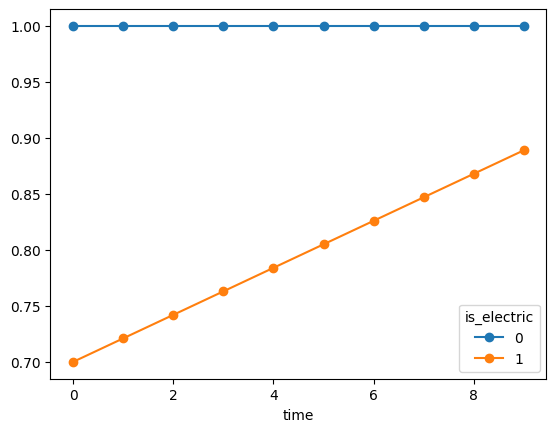

In [20]:
productivity.plot(x="time", hue="is_electric", marker="o")

In [21]:
obj_revenue = income_per_km * annual_mileage_km * (discount * productivity * R).sum()
obj_revenue

LinearExpression
----------------
+3.9e+06 R[0, 0, 0, 0] + 3.9e+06 R[0, 0, 0, 1] + 3.9e+06 R[0, 0, 0, 2] ... +2.185e+06 R[9, 4, 1, 4] + 2.185e+06 R[9, 4, 1, 5] + 2.185e+06 R[9, 4, 1, 6]

### Energy cost


In [22]:
fuel_consumption_l_per_km = 0.6
electricity_consumption_kwh_per_km = 2.5

energy_consumption = xr.DataArray(
    [fuel_consumption_l_per_km, electricity_consumption_kwh_per_km],
    dims=["is_electric"],
    coords={"is_electric": [0, 1]},
)

# Energy prices: vary by fuel type and time
initial_diesel_price = 18.0  # SEK/l
initial_electricity_price = 3.0  # SEK/kWh
diesel_price_growth = 0.01
electricity_price_growth = 0.00

diesel_prices = [
    initial_diesel_price * (1 + diesel_price_growth * t) for t in range(horizon)
]
electricity_prices = [
    initial_electricity_price * (1 + electricity_price_growth * t)
    for t in range(horizon)
]

energy_price = xr.DataArray(
    [[diesel_prices[t], electricity_prices[t]] for t in range(horizon)],
    dims=["time", "is_electric"],
    coords={"time": range(horizon), "is_electric": [0, 1]},
)

obj_energy_cost = (
    annual_mileage_km
    * (discount * productivity * energy_consumption * energy_price * R).sum()
)
obj_energy_cost

LinearExpression
----------------
+1.404e+06 R[0, 0, 0, 0] + 1.404e+06 R[0, 0, 0, 1] + 1.404e+06 R[0, 0, 0, 2] ... +5.463e+05 R[9, 4, 1, 4] + 5.463e+05 R[9, 4, 1, 5] + 5.463e+05 R[9, 4, 1, 6]

In [ ]:
# obj_salary_cost is a constant — excluded from linopy objective (does not affect optimal decisions).
m.add_objective(obj_revenue - obj_energy_cost, sense="max")

In [27]:
m.objective

Objective:
----------
LinearExpression: +3.9e+06 R[0, 0, 0, 0] + 3.9e+06 R[0, 0, 0, 1] + 3.9e+06 R[0, 0, 0, 2] ... -0 R[9, 2, 1, 6] - 0 R[9, 3, 1, 6] - 0 R[9, 4, 1, 6]
Sense: max
Value: None

In [28]:
R.sum()

LinearExpression
----------------
+1 R[0, 0, 0, 0] + 1 R[0, 0, 0, 1] + 1 R[0, 0, 0, 2] ... +1 R[9, 4, 1, 4] + 1 R[9, 4, 1, 5] + 1 R[9, 4, 1, 6]

In [29]:
# m.add_objective(R.sum(), sense="max", overwrite=True)

In [30]:
m.solve(solver_name="highs")

('ok', 'optimal')

In [31]:
x_sol = m.solution["x"]

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


In [32]:
x_sol

<xarray.DataArray 'x' (time: 10, fleet_slot: 5, is_electric: 2, age: 7,
                       decision: 3)> Size: 17kB
array([[[[[ 0.,  0.,  0.],
          [ 1.,  0.,  0.],
          [ 0.,  0.,  0.],
          ...,
          [ 0.,  0.,  0.],
          [ 0.,  0.,  0.],
          [ 0.,  0.,  0.]],

         [[ 0.,  0.,  0.],
          [ 0.,  0.,  0.],
          [ 0.,  0.,  0.],
          ...,
          [ 0.,  0.,  0.],
          [ 0.,  0.,  0.],
          [ 0.,  0.,  0.]]],


        [[[ 0.,  0.,  0.],
          [ 0.,  0.,  0.],
          [ 1.,  0.,  0.],
...
          [nan, nan, nan],
          [nan, nan, nan],
          [nan, nan, nan]]],


        [[[nan, nan, nan],
          [nan, nan, nan],
          [nan, nan, nan],
          ...,
          [nan, nan, nan],
          [nan, nan, nan],
          [nan, nan, nan]],

         [[nan, nan, nan],
          [nan, nan, nan],
          [nan, nan, nan],
          ...,
          [nan, nan, nan],
          [nan, nan, nan],
          [nan, nan, nan]]]]], shape=(10, 5, 2, 7, 3))
Coordinates:
  * time         (time) int64 80B 0 1 2 3 4 5 6 7 8 9
  * fleet_slot   (fleet_slot) int64 40B 0 1 2 3 4
  * is_electric  (is_electric) int64 16B 0 1
  * age          (age) int64 56B 0 1 2 3 4 5 6
  * decision     (decision) <U11 132B 'KEEP' 'REPLACE_DT' 'REPLACE_BET'

In [33]:
x_sol.sum(dim=["is_electric", "age"])  # .plot()  # .isel(fleet_slot=0)

<xarray.DataArray 'x' (time: 10, fleet_slot: 5, decision: 3)> Size: 1kB
array([[[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
...
        [1., 0., 0.],
        [1., 0., 0.]],

       [[0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]],

       [[0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])
Coordinates:
  * time        (time) int64 80B 0 1 2 3 4 5 6 7 8 9
  * fleet_slot  (fleet_slot) int64 40B 0 1 2 3 4
  * decision    (decision) <U11 132B 'KEEP' 'REPLACE_DT' 'REPLACE_BET'

In [34]:
active_decisions = (
    x_sol.fillna(0)
    .sum(
        ["is_electric", "age"]
    )  # collapse vehicle state → (time, fleet_slot, decision)
    .to_series()
    .rename("active")
    .reset_index()
    .query("active > 0.5")[["time", "fleet_slot", "decision"]]
    .reset_index(drop=True)
)
active_decisions

,time,fleet_slot,decision
0,0,0,KEEP
1,0,1,KEEP
2,0,2,KEEP
3,0,3,REPLACE_DT
4,0,4,REPLACE_DT
5,1,0,KEEP
6,1,1,KEEP
7,1,2,KEEP
8,1,3,KEEP
9,1,4,KEEP


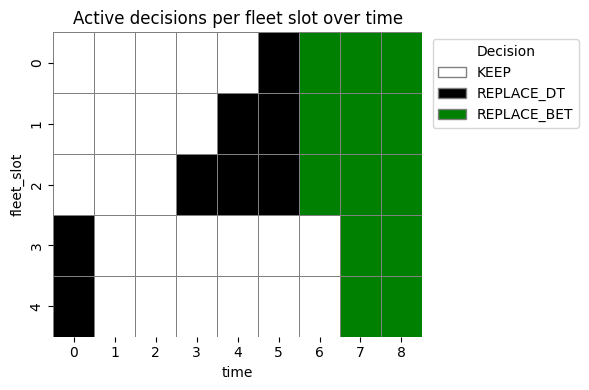

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

decision_color_map = {"KEEP": "white", "REPLACE_BET": "green", "REPLACE_DT": "black"}

active_decisions["decision_code"] = active_decisions["decision"].map(
    {d: i for i, d in enumerate(decisions)}
)

pivot = active_decisions.pivot(
    index="fleet_slot", columns="time", values="decision_code"
)
cmap = ListedColormap([decision_color_map[d] for d in decisions])

fig, ax = plt.subplots(
    figsize=(max(6, len(pivot.columns) * 0.6), max(4, len(pivot) * 0.5))
)
sns.heatmap(
    pivot,
    cmap=cmap,
    vmin=-0.5,
    vmax=len(decisions) - 0.5,
    linewidths=0.5,
    linecolor="grey",
    cbar=False,
    ax=ax,
)

patches = [
    mpatches.Patch(facecolor=decision_color_map[d], edgecolor="grey", label=d)
    for d in decisions
]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc="upper left", title="Decision")
ax.set_title("Active decisions per fleet slot over time")
plt.tight_layout()
plt.show()

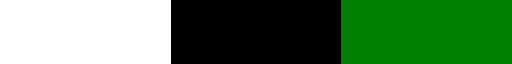

In [36]:
cmap